In [ ]:
#Import modules
import matplotlib.pyplot as plt
import numpy as np
from os import path
import tifffile
import time


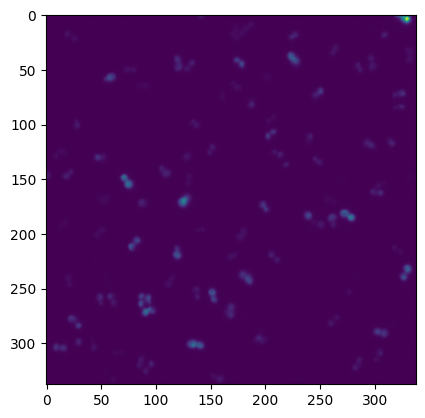

In [2]:
#Load image. In this tiff, channel 0 is green (MinD), channel 1 is red (MinE)
im = tifffile.imread("Example data/Yeast_variable_osci.tif")
plt.imshow(im[0,0])
im = im[:,0,:,:] #isolate MinD channel for downstream FFT analyses

Text(0, 0.5, 'Normalized fluorescence')

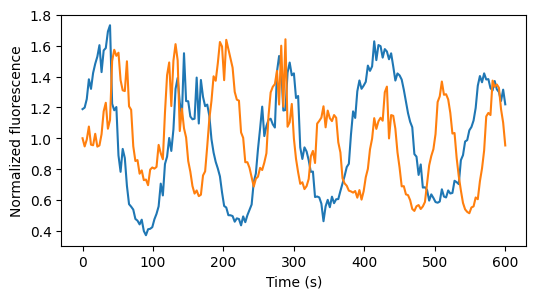

In [3]:
pixels = [[111,201],[264,63]] #single pixels from two example cells. [y,x]
time_series = []
for p in pixels:
    signal = im[:,p[0],p[1]]
    mean_signal = np.mean(signal,axis = 0)
    time_series.append(signal/mean_signal)

times = np.arange(0,201) * 3

f, ax1 = plt.subplots(1, 1,figsize = (6, 3))
for series in time_series:
    ax1.plot(times,series)

plt.xlabel("Time (s)")
plt.ylabel("Normalized fluorescence")

In [4]:
#non- torch accelerated FFT - good enough for small images. Use the torch rfft for whole-image processing
fft = np.fft.fft(im, axis = 0)[3:int(im.shape[0]/5)] #indexing away first few frames gets rid of DC component
#dividing by 5 truncates the tail end of the FFT spectrum. remove it to see the "mirror image" nature of the FFT

In [5]:
ps=np.abs(fft) #apply FFT along the time axis and collect the frequency (bin) and power (intensity). This is the absolute of the intensity,
ps_norm = ps/np.sum(ps,axis=0) #normalizes power spectrum    

Text(0, 0.5, 'Relative amplitude')

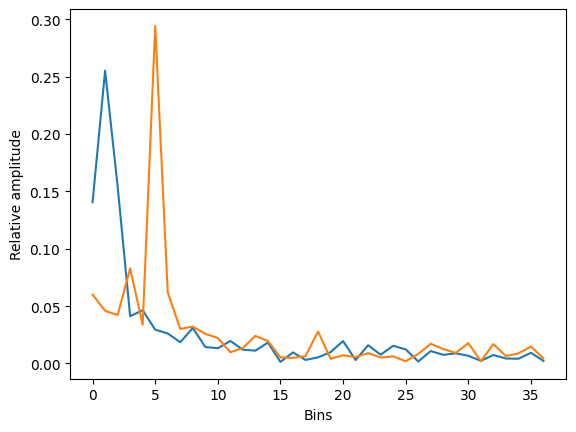

In [6]:
for p in pixels:
    plt.plot(ps_norm[:,p[0],p[1]])
plt.xlabel("Bins") #remember that we removed the first 3 bins here
plt.ylabel("Relative amplitude")

# Above, basic demo of converting time-variable signal to FFT.
Below, applied snippets from actual code pipeline for FFT generation with torch, image coloration, etc.

In [7]:
import torch
#detrend timeseries centers the oscillation around 0 and aims to remove the DC component of the FFT (without truncation)
def detrend_timeseries(Y):
    start_time = time.time()
    T, H, W = Y.shape
    
    #make the time-axis to use in the fit
    t = torch.arange(T, dtype=Y.dtype, device=Y.device) #offers option for on-GPU is you have your array there
    
    # Compute sums for computing the coefficients
    sum_t = t.sum()
    sum_t2 = (t ** 2).sum()
    n = T
    
    sum_y = Y.sum(dim=0)
    sum_ty = (Y * t.view(-1, 1, 1)).sum(dim=0)
    
    # Compute coefficients a (slope) and b (intercept)
    denominator = sum_t2 - (sum_t ** 2) / n
    a = (sum_ty - (sum_t * sum_y) / n) / denominator
    b = (sum_y - a * sum_t) / n
    
    # Calculate and subtract the trend
    trend = a.unsqueeze(0) * t.view(-1, 1, 1) + b.unsqueeze(0)
    print("--- %s seconds ---" % (time.time() - start_time))
    del t, sum_t, sum_t2, n, sum_y, sum_ty, denominator, a, b
    return Y - trend


In [8]:
c_im_torch = torch.from_numpy(im.astype('float32')) #convert im to tensor
c_im_c=detrend_timeseries(c_im_torch)

--- 0.0294952392578125 seconds ---


In [9]:
fft_c = torch.fft.rfft(c_im_c,axis=0).detach().numpy()[0:40] #just getting first 40 frames for better visualization down the line
ps=np.abs(fft_c) 
ps_norm = ps/np.sum(ps,axis=0)  
ps_norm.shape

(40, 338, 338)

In [10]:
frames = np.arange(1,ps_norm.shape[0]+1)
freqs = frames*((1/3)/201)*1000  #Bins to frequency conversion. mHz = frames * ((1/sampling_period)/(number_of_frames)) * 1000
#This image was a 10-minute timeseries with a 3-second sampling period
freq_series = []
for p in pixels:
    freq_series.append(ps_norm[:,p[0],p[1]])


Text(0, 0.5, 'Relative amplitude')

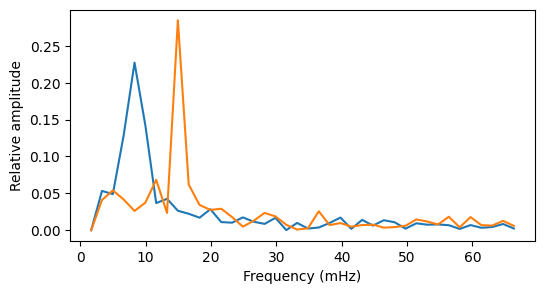

In [11]:
#Plotting the FFT spectra for the two example pixels from separate cells
f, ax1 = plt.subplots(1, 1,figsize = (6, 3))
for series in freq_series:
    ax1.plot(freqs,series)
#plt.yticks([]);
plt.xlabel("Frequency (mHz)")
plt.ylabel("Relative amplitude")

# Generating frequency-colored image
You can do this manually in imageJ by saving the ps to tiff, then using the "temporal color code" function. Below is a way to do it in python.

In [12]:
def temporalColorCode(img,cmap='turbo',proj='max'):
    slices,x,y=img.shape
    cc=plt.colormaps.get_cmap(cmap).resampled(slices)(range(slices))
    CC=np.broadcast_to(cc,(x,y,slices,4)).swapaxes(0,2)[:,:,:,0:3].T
    outstack=((CC*(img.T).swapaxes(0,1)).T)
    if proj=='max':
        out=(outstack.max(axis=0)).swapaxes(0,1)
    elif proj=='sum':
        out=(outstack.sum(axis=0)).swapaxes(0,1)
    return out
from matplotlib.colors import ListedColormap

In [13]:
#python for FFT coloration
fft_start = 3 #Set frame range for start and end of colorbar (bins, not mHz)
fft_end = 10
t_ps = temporalColorCode(ps[fft_start:fft_end,:,:]) #generally more vibrant
t_ps_norm = temporalColorCode(ps_norm[fft_start:fft_end,:,:]) #more even color intensities due to normalization
fft_path = "Example data/code_output/"
point_name = "yeast_example"
tifffile.imwrite(fft_path +  "{}_FFT_color_{}-{}.tiff".format(point_name,fft_start,fft_end),t_ps)
tifffile.imwrite(fft_path +  "{}_FFT_norm_color_{}-{}.tiff".format(point_name,fft_start,fft_end), t_ps_norm)

### above files are openable in fiji/imageJ. Below, showing them in python with the colorbar

In [14]:
fr_rate = 3
num_frames = im.shape[0]
mHz_conv = ((1/fr_rate)/num_frames)*1000
freq_range = [fft_start* mHz_conv, fft_end * mHz_conv]
print("Freq range in mHz = ", freq_range)

Freq range in mHz =  [4.975124378109452, 16.583747927031506]


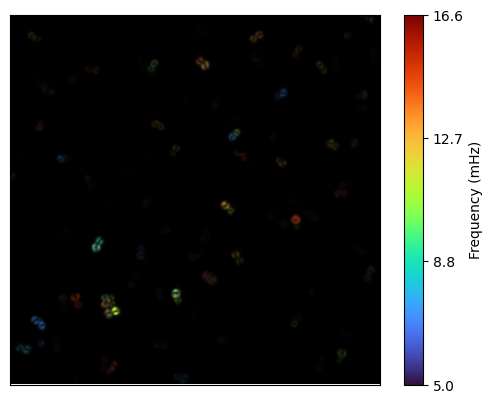

In [15]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.image as mpimg

#PS, high-amplitude cells pop out

fig, ax = plt.subplots()
ax.imshow(t_ps / t_ps.max())  # normalize to [0,1] for RGB display
plt.xticks([])
plt.yticks([])
sm = ScalarMappable(cmap='turbo', norm=Normalize(vmin=freq_range[0], vmax=freq_range[-1]))
sm.set_array([])

cbar_ticks = np.linspace(freq_range[0],freq_range[1],4)

cbar = fig.colorbar(sm, ax=ax, ticks=cbar_ticks,format='{x:.1f}')
cbar.set_label('Frequency (mHz)')
plt.show()


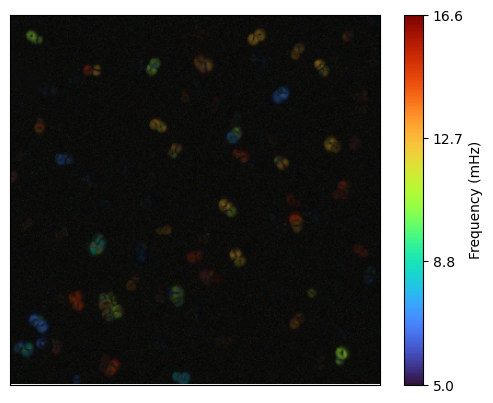

In [16]:
#PS-norm: more even intensity across cells

fig, ax = plt.subplots()
gamma = 0.9
ax.imshow(t_ps_norm ** gamma)  # already normalized, gamma increases brightness

sm = ScalarMappable(cmap='turbo', norm=Normalize(vmin=freq_range[0], vmax=freq_range[-1]))
sm.set_array([])
plt.xticks([])
plt.yticks([])
cbar_ticks = np.linspace(freq_range[0],freq_range[1],4)

cbar = fig.colorbar(sm, ax=ax, ticks=cbar_ticks,format='{x:.1f}')
cbar.set_label('Frequency (mHz)')
plt.show()